# Day 3 — Time Series Decomposition

Bu notebook'ta temiz Google Trends zaman serisinin yapısı incelenecektir.

Amaç, gözlemlenen zaman serisini temel bileşenlerine ayırmaktır:

- Trend
- Seasonality
- Residual

Analiz haftalık temiz veri üzerinde yapılacaktır.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose



# Python'da Kütüphane Kullanımı ve Zaman Serisi Analizi

Python'da dışarıdan kurulan kütüphaneleri veya Python'un kendi modüllerini kullanabilmek için `import` komutundan faydalanırız. Bu projede zaman serisi analizi yapmak için **`statsmodels`** kütüphanesini kullanacağız.

---

## 1. Kurulum (Install) ve İçe Aktarma (Import) Arasındaki Fark

Bir kütüphaneyi bilgisayara kurmak ile Python kodu içerisinde kullanmak aynı şey değildir.

* **`pip install`:** Kütüphaneyi bilgisayarınıza indirir ve kurar.
* **`import`:** Kurulu olan kütüphaneyi mevcut Python programınızda veya Notebook'unuzda kullanıma açar.

```bash
# Kurulum komutu (Terminal veya Notebook hücresinde !pip şeklinde çalıştırılır)
pip install statsmodels

```

```python
# Kodu projeye dahil etme komutu
import statsmodels

```

> 💡 **Basit Bir Benzetme:**
> * **`pip install`** → Kitabı satın alıp kitaplığa koymak.
> * **`import`** → Kitabı raftan alıp masaya (çalışma alanına) koymak.
> 
> 

---

## 2. Python'da Import Yöntemleri

Python'da kütüphaneleri çalışma ortamına çağırırken farklı yöntemler kullanabiliriz.

### Temel Import

Modülü doğrudan kullanıma açar.

```python
import pandas
pandas.read_csv(...) # Kullanımı

```

### `as` ile İsimlendirme

Modüle daha kısa ve pratik bir takma ad (alias) vermek için kullanılır.

```python
import pandas as pd
import matplotlib.pyplot as plt

pd.read_csv(...) # Kullanımı daha kısadır

```

### `from ... import ...` Yapısı

Bir paketin tamamını değil, **sadece içerisindeki belirli bir fonksiyonu veya sınıfı** almak istiyorsak kullanılır. İşlemi hızlandırır ve belleği yormaz.

```python
from math import sqrt
sqrt(25) # "math.sqrt()" yazmak yerine doğrudan çağırabiliriz

```

---

## 3. `statsmodels` Kütüphanesi ve Kullanımı

**`statsmodels`**; Python'da istatistiksel analiz, regresyon, modelleme ve zaman serisi analizi gibi işlemler için kullanılan güçlü bir kütüphanedir. Biz bu projede veriyi **trend, seasonality ve residual** bileşenlerine ayırmak için kullanacağız.

Projeye dahil ettiğimiz kod satırı şu şekildedir:

```python
from statsmodels.tsa.seasonal import seasonal_decompose

```

Neden `import statsmodels` yazmak yerine bu uzun yapıyı kullandık? Çünkü paketin tamamına değil, sadece `seasonal_decompose` fonksiyonuna ihtiyacımız var.

### Bu İfadeyi Adım Adım İnceleyelim:

* **`statsmodels`:** Ana Python kütüphanesidir.
* **`tsa` (Time Series Analysis):** Kütüphane içindeki "Zaman Serisi Analizi" bölümüdür. Google Trends verileri tarih sırasına göre değiştiği için bir zaman serisi oluşturur.
* **`seasonal`:** Mevsimsellik ve ayrıştırma (decomposition) işlemlerinin bulunduğu alt modüldür.
* **`seasonal_decompose`:** Zaman serisini temel bileşenlerine (trend, mevsimsellik vb.) ayırmak için kullandığımız asıl fonksiyondur.

---

## 4. Zaman Serisi Bileşenleri (`seasonal_decompose`)

Zaman içindeki değişimi gösteren verilerin (örneğin Google Trends verisi) grafiğine baktığımızda yalnızca toplam hareketi görürüz. Ancak bu toplam hareket, kendi içinde farklı bileşenlerin birleşiminden oluşur.

`seasonal_decompose` fonksiyonu veriyi aşağıdaki temel bileşenlere ayırır:

1. **Observed (Gözlemlenen):** Doğrudan veri setinde gördüğümüz, gerçek ve ham zaman serisidir (Örn: *15 → 18 → 17 → 21*).
2. **Trend (Eğilim):** Serinin uzun vadeli genel yönünü gösterir. Kısa süreli küçük iniş çıkışlardan ziyade genel bir yükseliş (örn: *15 → 20 → 25*) veya düşüş yönünü ifade eder.
3. **Seasonality (Mevsimsellik):** Belirli zaman aralıklarında düzenli olarak tekrar eden davranışlardır (Örn: *Her Aralık ayında yükseliş, her Ocak ayında düşüş*).
* *Not: Tek seferlik ani bir sıçrama (örn: bir haftada 20'den 100'e çıkması) mevsimsellik sayılmaz; hareketin periyodik olması gerekir.*


4. **Residual (Kalıntı/Hata):** Trend ve mevsimsellik etkileri veriden çıkarıldıktan sonra geriye kalan açıklanamayan değişimlerdir. İçerisinde beklenmedik dalgalanmalar, ani sıçramalar (spike'lar), rastgele değişimler ve özel olayların etkileri bulunur.

### Additive Decomposition (Toplamsal Ayrıştırma) Mantığı

Basit bir toplamsal yaklaşımda, zaman serisinin şu denklemle oluştuğu varsayılır:

> **Observed = Trend + Seasonality + Residual**
> *(Gördüğümüz hareket = Uzun vadeli yön + Tekrar eden hareketler + Açıklanamayan değişimler)*

---

## 5. Projenin Genel Akışı

Bu analiz sayesinde, yalnızca grafiğin genel şekline bakmakla kalmayıp zaman serisinin hangi bileşenlerden oluştuğunu derinlemesine inceleyebileceğiz.

**Uygulanan Adımlar:**

1. Google Trends Verisi
2. Veri Temizleme ve Hazırlık
3. Zaman Serisine Dönüştürme
4. `statsmodels` Kütüphanesinin Çağırılması
5. `seasonal_decompose()` ile Analiz
6. **Sonuçların İncelenmesi:** *Observed, Trend, Seasonal, Residual*

In [5]:
clean_data= pd.read_csv( "../data/processed/google_trends_ai_3y_clean.csv",
    index_col="date",
    parse_dates=["date"])

In [ ]:
clean_data.shape

In [ ]:
clean_data.head()

In [6]:
chatgpt_decomposition = seasonal_decompose( # bu o import ettiğimiz fonksiyon
    clean_data["chatgpt"],
    model="additive",
    period=52,
)

In [ ]:
chatgpt_decomposition.plot()
plt.show()

# ChatGPT Seasonal Decomposition Sonuçlarının Yorumlanması

ChatGPT Google Trends zaman serisi `seasonal_decompose()` kullanılarak
dört bileşen halinde incelendi.

## Observed

`Observed`, veri setindeki gerçek zaman serisidir.

Grafikte ChatGPT ilgisinin zaman içerisinde genel olarak yükseldiği,
2025 yılında daha yüksek seviyelere ulaştığı ve daha sonraki dönemde
yükseliş hızının azalarak daha yatay bir yapı gösterdiği görülmektedir.

---

## Trend

`Trend`, kısa dönemli dalgalanmalar azaltıldıktan sonra serinin uzun
vadeli genel yönünü gösterir.

ChatGPT trendinde:

- başlangıçta daha düşük ilgi,
- zaman içerisinde belirgin yükseliş,
- sonraki dönemde yükseliş hızının azalması

gözlenmektedir.

### Trend Grafiğinin Başında ve Sonunda Neden Değer Yok?

Trend hesabı bir tarihin hem önceki hem sonraki gözlemlerinden
yararlanabilir.

Verinin başlangıcında yeterli geçmiş gözlem, sonunda ise yeterli gelecek
gözlem bulunmadığı için bazı uç noktalarda trend hesaplanamaz.

Bu noktalar `NaN` olur ve grafikte çizilmez.

Bu durum veri kaybı değil, decomposition yönteminin hesaplama
özelliğidir.

---

## Seasonal

`Seasonal`, belirli aralıklarla tekrar eden hareketleri temsil eder.

Analizde:

```python
period=52

kullanılmıştır.

Veri haftalık olduğu için 52 gözlem yaklaşık bir yıla karşılık gelir.

Bu nedenle fonksiyon yaklaşık 52 haftada tekrar eden bir desen
aramaktadır.

Önemli olarak, period=52 değerini algoritma kendisi keşfetmemiştir.
Bu periyot analiz sırasında varsayım olarak verilmiştir.

Bu nedenle seasonal grafiğin tekrar eden bir yapı göstermesi tek başına
ChatGPT ilgisinde kesin yıllık seasonality bulunduğunu kanıtlamaz.

Yaklaşık 157 haftalık veri bulunduğu için analizde yaklaşık üç yıllık
döngü bulunmaktadır.

Bu nedenle sonuç:

"52 haftalık periyot varsayımı altında yıllık mevsimsel yapı"
incelenmiştir."

şeklinde yorumlanmalıdır.


## Residual

Residual, trend ve seasonal bileşenler çıkarıldıktan sonra geriye kalan
hareketleri temsil eder.

Basit additive yaklaşım:

Observed = Trend + Seasonal + Residual

şeklindedir.

Dolayısıyla:

Residual = Observed - Trend - Seasonal

olarak düşünülebilir.

Residual değerlerinin sıfıra yakın olması, ilgili gözlemin trend ve
seasonality tarafından büyük ölçüde açıklanabildiğini gösterir.

Sıfırdan çok uzak noktalar ise:

ani yükselişler,
ani düşüşler,
özel olaylar,
beklenmeyen değişimler,
rastgele dalgalanmalar

ile ilişkili olabilir.

Ancak residual grafiği bu hareketlerin nedenini tek başına açıklamaz.

# Daha Basit Anlatım

Elimizde şu var:

```text
Tarih        ChatGPT ilgisi
2023 ...     15
2024 ...     25
2025 ...     70
2026 ...     68
```

Bunu grafik yaptığımızda tek bir zikzaklı çizgi görüyoruz:

```text
        /\      /\
   ____/  \____/  \__
__/
```

Ama bu çizginin içinde farklı türde hareketler birbirine karışmış olabilir. Bizim sorumuz şu:

> “Bu çizgi neden böyle görünüyor?”

İşte **decomposition = parçalarına ayırma** tam olarak bunun için.

Bunu bir içeceğe benzet:

```text
Limonata
=
su
+ limon
+ şeker
```

Elimizde sadece limonatayı görüyorsun. Ama “içinde neler var?” diye ayırabiliyorsun.

Zaman serisinde de:

```text
Gördüğümüz gerçek çizgi
=
Trend
+
Seasonal
+
Residual
```

Şimdi sadece bu üçüne odaklan.

### 1. Trend = uzun vadede nereye gidiyor?

Mesela verin:

```text
15 → 17 → 14 → 20 → 18 → 25 → 23 → 35 → 40
```

Çok zikzak var.

Ama uzaktan bakınca:

```text
15 → 20 → 25 → 35 → 40
```

gibi genel olarak yukarı gidiyor.

İşte **trend** bunu gösteriyor.

Senin ChatGPT grafiğinde trend kabaca:

```text
20
 ↓
30
 ↓
45
 ↓
60
 ↓
70+
```

olmuş.

Yani bize:

> “Tek tek haftaları boş ver; ChatGPT arama ilgisinin uzun vadeli yönü ne?”

sorusunun cevabını veriyor.

**Niye lazım?** Çünkü ileride tahmin yapacağız. Bir serinin genel olarak yükseldiğini mi, düştüğünü mü, yataylaştığını mı bilmek çok önemli.

---

### 2. Seasonal = düzenli tekrar eden hareket var mı?

Örneğin dondurma aramalarını düşün.

Her yıl:

```text
Kış    → düşük
Yaz    → yüksek
Kış    → düşük
Yaz    → yüksek
```

gibi davranıyorsa buna **seasonality / mevsimsellik** deriz.

Yani olay sadece “yükseldi-düştü” değil.

Önemli olan:

> **Aynı desen tekrar ediyor mu?**

Bizim veri **haftalık** olduğu için:

```python
period=52
```

dedik.

Çünkü yaklaşık:

```text
52 hafta = 1 yıl
```

Yani `seasonal_decompose` fonksiyonuna:

> “ChatGPT ilgisinde yaklaşık her 1 yılda tekrar eden bir desen var mı, bir bak.”

diyoruz.

Çok önemli: Biz burada **“kesin yıllık seasonality vardır” demiyoruz.** Sadece 52 haftalık tekrar varsayımını inceliyoruz.

---

### 3. Residual = diğer ikisi açıklayamadıysa geriye ne kaldı?

Diyelim trend bize:

> “Bu hafta yaklaşık 60 civarında olmasını bekliyorum.”

diyor.

Seasonality de:

> “Bu dönemde normalde +5 civarında bir etki oluyor.”

diyor.

O zaman kabaca beklenti:

```text
60 + 5 = 65
```

olsun.

Ama gerçek Google Trends değeri:

```text
82
```

çıktı.

Aradaki fazlalık:

```text
82 - 65 = 17
```

gibi bir şey.

İşte o açıklanamayan bölüm **residual**.

Mesela bir ürün duyurusu olmuş olabilir, büyük bir haber çıkmış olabilir, rastgele bir spike olabilir.

Ama residual bize **neden** olduğunu söylemez. Sadece:

> “Burada trend ve düzenli tekrarın açıklayamadığı sıra dışı bir hareket var.”

der.

---

Şimdi senin grafiğini yeniden okuyalım:

```text
1. grafik
ChatGPT
```

Bu **gerçek veri**. Hiç parçalamadan önceki hali.

```text
2. grafik
Trend
```

Zikzakları azaltıp uzun vadeli yönü gösteriyor.

```text
3. grafik
Seasonal
```

“52 haftada tekrar eden bir desen varsayarsak bunun tekrar eden kısmı neye benziyor?” diyor.

```text
4. grafik
Resid
```

İlk üç parçadan açıklanamayan tuhaflıkları gösteriyor.

En önemli soru da: **Bunu niye yapıyoruz?**

Çünkü haftaya/modelleme aşamasına geçtiğimizde sadece:

> “ChatGPT 70 olmuş.”

demek istemiyoruz.

Şunu anlamak istiyoruz:

> “Bu 70'in ne kadarı uzun vadeli yükselişten geliyor? Düzenli tekrar eden yapı var mı? Ne kadarı beklenmedik hareket?”

İşte decomposition bunun için.

Notebook’una koyabileceğin en sade not:

```markdown
# Time Series Decomposition Mantığı

Time series decomposition, zaman serisini daha kolay anlayabilmek için
farklı bileşenlere ayırma işlemidir.

Temel fikir:

Observed = Trend + Seasonal + Residual

## Observed

Gerçekte gözlemlediğimiz zaman serisidir.

Örneğin Google Trends'ten aldığımız haftalık ChatGPT değerleri.

## Trend

Serinin uzun vadeli genel yönünü gösterir.

Kısa dönemli iniş çıkışlardan çok:

- genel olarak yükseliyor mu,
- düşüyor mu,
- yatay mı gidiyor

sorusuna cevap verir.

## Seasonal

Belirli aralıklarla tekrar eden düzenli hareketleri gösterir.

Örneğin her yıl benzer aylarda tekrar eden bir yükseliş veya düşüş
seasonality olabilir.

Verimiz haftalık olduğu için:

period=52

yaklaşık 1 yıllık tekrar eden bir yapı olup olmadığını incelemek için
kullanılmıştır.

Bu, kesin olarak yıllık seasonality bulunduğu anlamına gelmez.
52 haftalık bir tekrar varsayımı incelenmektedir.

## Residual

Trend ve seasonal bileşenlerin açıklayamadığı hareketlerdir.

Ani spike'lar, beklenmeyen düşüşler veya özel olayların etkileri burada
görülebilir.

Residual bu hareketlerin nedenini açıklamaz; yalnızca normal yapıdan
sapmayı gösterir.

## Neden Decomposition Yapıyoruz?

Amaç yalnızca grafiğin yükselip düştüğünü görmek değil, hareketin
kaynağını daha iyi anlamaktır.

Gerçek veri
    ↓
Uzun vadeli yön nedir?       → Trend
Tekrar eden yapı var mı?     → Seasonal
Geriye ne kaldı?             → Residual

Bu bilgi daha sonraki forecasting modellerini kurmadan önce zaman
serisinin yapısını anlamamıza yardımcı olur.
```



# Bir örnek üstünden

Bu üçünü (Trend + Seasonal + Residual) topluca bir araya getirdiğinde, orijinal verinin ta kendisini (Observed) elde edersin. Yani senin o en başta Google Trends'ten indirdiğin, o inişli çıkışlı, ham ChatGPT grafiğini gösterir.

Düşün ki bir araba yolculuğundasın ve hızını kaydediyorsun:

* Trend (Ana Gidişat): Otoyola çıktın ve genel olarak hızlanıyorsun. Hedefine doğru uzun vadeli, ana eğilimin bu.

* Seasonal (Mevsimsellik): Yol üzerinde her 50 kilometrede bir gişeler var. Her gişeye geldiğinde düzenli olarak yavaşlıyor, sonra tekrar hızlanıyorsun. Bu senin beklenen ve periyodik ritmindir.

* Residual (Kalıntı): Yolda aniden önüne bir çukur çıkıyor veya anlık bir fırtına kopuyor, hızını mecburen aniden değiştiriyorsun. Bu ise beklenmedik, tamamen rastgele ve açıklanamayan sürprizlerdir.

İşte sonuç: Senin yolculuk boyunca yaptığın gerçek hızın (orijinal veri), bu üçünün toplamıdır.

Zaman serisi analizi (seasonal_decompose), grafiğe bakıp "Ya bu çizgi neden sürekli inip çıkıyor?" diye sorduğunda sana şu cevabı verir:

"Çünkü uzun vadede yönü bu (Trend), her hafta şu düzenli alışkanlıkları yapıyor (Seasonal) ve arada da böyle beklenmedik şoklar yemiş (Residual).

In [ ]:
chatgpt_decomposition.trend.head(10)

In [7]:
start_trend= chatgpt_decomposition.trend.dropna().head(1)#NaN olan değerleri atıp yalnızca hesaplanabilmiş trend değerlerini bırakır.

In [8]:
last_trend= chatgpt_decomposition.trend.dropna().tail(1)

In [9]:
print(start_trend, last_trend)

date
2024-01-28    20.317308
Name: trend, dtype: float64 date
2026-01-25    73.730769
Name: trend, dtype: float64


In [ ]:
first_trend = chatgpt_decomposition.trend.dropna().iloc[0]
last_trend = chatgpt_decomposition.trend.dropna().iloc[-1] #-1 Python'da sondan birinci anlamına geliyor.

print("İlk trend değeri:", first_trend)
print("Son trend değeri:", last_trend)

İlk trend değeri: 20.317307692307693
Son trend değeri: 73.73076923076923


.loc   → etikete/index adına göre seçer
.iloc  → sıra numarasına göre seçer

# Trend Değerlerini Sayısal Olarak İncelemek

Decomposition sonucundaki trend bileşeni:

```python
chatgpt_decomposition.trend

ile elde edilebilir.

Trend serisinin başlangıç ve bitiş kısımlarında bazı değerler NaN
olabileceği için:

chatgpt_decomposition.trend.dropna()

kullanılarak yalnızca hesaplanabilmiş trend değerleri incelenebilir.

head() ve tail()
chatgpt_decomposition.trend.dropna().head()

hesaplanabilmiş ilk trend değerlerini gösterir.

chatgpt_decomposition.trend.dropna().tail()

hesaplanabilmiş son trend değerlerini gösterir.

Bu iki bölüm karşılaştırılarak serinin uzun vadeli yönü hakkında fikir
edinilebilir.

.iloc

.iloc, Pandas'ta sıra numarasına göre seçim yapmak için kullanılır.

.iloc[0]

ilk elemanı,

.iloc[-1]

son elemanı seçer.

Örneğin:

10, 20, 30, 40

serisinde:

iloc[0]  → 10
iloc[-1] → 40

olur.

.loc ile .iloc arasındaki temel fark:

.loc  → index etiketi/değeri ile seçim
.iloc → sıra numarası ile seçim

Bu nedenle:

first_trend = chatgpt_decomposition.trend.dropna().iloc[0]
last_trend = chatgpt_decomposition.trend.dropna().iloc[-1]

ile trendin hesaplanabilmiş ilk ve son değerleri karşılaştırılabilir.

In [11]:
chatgpt_decomposition.seasonal.head(15)

date
2023-07-30   -4.174464
2023-08-06   -1.193695
2023-08-13   -3.203310
2023-08-20   -1.150425
2023-08-27    1.931305
2023-09-03    1.960152
2023-09-10    5.945729
2023-09-17    9.460152
2023-09-24    3.979382
2023-10-01    3.993805
2023-10-08    6.537075
2023-10-15    7.585152
2023-10-22    6.628421
2023-10-29    3.671690
2023-11-05    7.200536
Name: seasonal, dtype: float64

In [20]:
chatgpt_decomposition.seasonal.shape

(157,)

In [ ]:
print(chatgpt_decomposition.seasonal.iloc[0],
chatgpt_decomposition.seasonal.iloc[52])

-4.174463757396448 -4.174463757396448



Buradaki `period=52` parametresi, çıktının toplam satır sayısını (shape) değil, verinin **içerisindeki döngünün (pattern) uzunluğunu** belirler.

Sistem temelde şu şekilde çalışır:

1. **Orijinal Veri Uzunluğu Korunur:** Sen fonksiyona 157 haftalık (yaklaşık 3 yıllık) bir veri verdin. `statsmodels`, ayrıştırma işleminden sonra `Trend`, `Seasonal` ve `Residual` serilerini de orijinal verinle aynı boyutta (157 satır) oluşturur. Böylece her bir tarihin tam karşılığına denk gelen değeri görebilirsin.

2. **Döngü Döşenir:** `period=52` diyerek algoritmaya, "Burada 52 haftada bir kendini tekrar eden bir desen var" demiş oldun. Algoritma bu 52 haftalık ideal döngüyü hesaplar ve 157 satırlık tablonun tamamına bunu adeta kopyala-yapıştır yapar.

Yazılımsal bir mantıkla düşünürsek (örneğin dizilerde kullandığımız *mod alma (modulo)* işlemi gibi):

* 1. satır ile 53. satırın (1 + 52) `seasonal` değeri birebir aynıdır.


* 2. satır ile 54. satırın (2 + 52) değeri aynıdır.


* Bu döngü 157 satır dolana kadar kendini tekrar eder.

Eğer `chatgpt_decomposition.seasonal` sadece 52 satır döndürseydi, bunu 157 satırlık orijinal veri setinle eşleştiremez, matematiksel işleme sokamaz veya grafikte yan yana çizdiremezdin.

Kısacası; **157** senin toplam veri uzunluğun, **52** ise o verinin içine yerleştirilmiş tekrar eden döngünün periyodudur. Eğer `chatgpt_decomposition.seasonal.iloc[0]` ile `chatgpt_decomposition.seasonal.iloc[52]` değerlerini kontrol edersen, tamamen aynı sayılar olduklarını görebilirsin.

In [12]:
chatgpt_decomposition.seasonal.max()

np.float64(11.037074704142011)

In [13]:
chatgpt_decomposition.seasonal.min()

np.float64(-18.419656065088756)

In [14]:
seasonal_max_date = chatgpt_decomposition.seasonal.idxmax() # hangi tarihlerde olduğunu görmek için
seasonal_min_date = chatgpt_decomposition.seasonal.idxmin()

print("En yüksek seasonal tarih:", seasonal_max_date)
print("En düşük seasonal tarih:", seasonal_min_date)

En yüksek seasonal tarih: 2024-03-31 00:00:00
En düşük seasonal tarih: 2023-12-31 00:00:00


Ama çok önemli: Eğer mesela 2024-03-... seasonal maksimum çıktı diye:

“Her yıl martta kesin yükseliyor.”

demiyoruz.

In [15]:
chatgpt_decomposition.resid.dropna().head()

date
2024-01-28    2.083118
2024-02-04    1.136002
2024-02-11    2.544656
2024-02-18    1.910041
2024-02-25    3.270618
Name: resid, dtype: float64

* Residual pozitifse:

Gerçek değer, trend + seasonal beklentisinden daha yüksek çıkmış.

* Negatifse:

Daha düşük çıkmış.

In [ ]:
chatgpt_decomposition.resid.dropna().abs().nlargest(5)

# Residual’daki NaN’leri çıkar, değerlerin mutlak büyüklüğünü al ve en büyük 5 sapmayı getir.
# Bunu yapıyoruz çünkü hem çok büyük pozitif hem de çok büyük negatif sapmalar bizim için “sıra dışı”.

date
2025-03-30    13.491771
2024-03-31    12.594767
2025-09-14     8.559079
2025-08-03     7.693695
2024-09-15     7.662075
Name: resid, dtype: float64

bu tarihlerdeki gerçek residual değerlerini çekelim:

In [29]:
largest_residual_dates = (
    chatgpt_decomposition.resid
    .dropna()
    .abs()
    .nlargest(5)
    .index
)

In [30]:
largest_residuals = chatgpt_decomposition.resid.loc[
    largest_residual_dates
]

largest_residuals

date
2025-03-30    13.491771
2024-03-31   -12.594767
2025-09-14     8.559079
2025-08-03     7.693695
2024-09-15    -7.662075
Name: resid, dtype: float64

# Residual Sonuçlarının İş Yorumu

En büyük residual sapmalar:

| Tarih | Residual | Yorum |
|---|---:|---|
| 2025-03-30 | +13.49 | Beklenenden belirgin şekilde daha yüksek ilgi |
| 2024-03-31 | -12.59 | Beklenenden belirgin şekilde daha düşük ilgi |
| 2025-09-14 | +8.56 | Beklenen seviyenin üzerinde ilgi |
| 2025-08-03 | +7.69 | Beklenen seviyenin üzerinde ilgi |
| 2024-09-15 | -7.66 | Beklenen seviyenin altında ilgi |

Pozitif residual, gerçek Google Trends değerinin trend ve seasonal
bileşenlerin oluşturduğu beklentiden daha yüksek olduğunu gösterir.

Negatif residual ise gerçek değerin beklentiden daha düşük olduğunu gösterir.

Özellikle 2024-03-31 ve 2025-03-30 tarihlerinin yılın benzer dönemlerine
denk gelmesine rağmen zıt yönde güçlü sapmalar göstermesi dikkat çekicidir.

Bu durum, ilgili hareketlerin yalnızca yıllık seasonality ile
açıklanamayabileceğini ve ürün duyuruları, haberler veya diğer dış olayların
etkisinin araştırılması gerektiğini düşündürmektedir.

Residual değeri yüzde değişim değildir. Additive decomposition içerisinde
Google Trends'in 0–100 ölçeğinde trend + seasonal beklentisinden olan sapmayı
ifade eder.

In [43]:
decomposition_df = pd.DataFrame(
    {
        "observed": chatgpt_decomposition.observed,
        "trend": chatgpt_decomposition.trend,
        "seasonal": chatgpt_decomposition.seasonal,
        "residual": chatgpt_decomposition.resid,
        "yaklaşık beklenen": round(chatgpt_decomposition.trend+ chatgpt_decomposition.seasonal,1),
        "gözlemlenen": chatgpt_decomposition.trend + chatgpt_decomposition.seasonal+ chatgpt_decomposition.resid,
    }
)

In [44]:
important_dates_df = decomposition_df.loc[ # önemli residulların olduğu tarihleri seç
    largest_residual_dates
]

important_dates_df

,observed,trend,seasonal,residual,yaklaşık beklenen,gözlemlenen
date,,,,,,
2025-03-30,83.0,58.471154,11.037075,13.491771,69.5,83.0
2024-03-31,21.0,22.557692,11.037075,-12.594767,33.6,21.0
2025-09-14,91.0,72.980769,9.460152,8.559079,82.4,91.0
2025-08-03,77.0,70.500000,-1.193695,7.693695,69.3,77.0
2024-09-15,35.0,33.201923,9.460152,-7.662075,42.7,35.0


# Decomposition Tablosunun İş Yorumu

Decomposition sonucunda her gözlem şu şekilde açıklanabilir:

Observed = Trend + Seasonal + Residual

- `Observed`: Gerçekte gözlenen Google Trends değeri
- `Trend`: Uzun vadeli temel ilgi seviyesi
- `Seasonal`: Yılın ilgili dönemine ait tekrar eden etki
- `Residual`: Trend ve seasonal bileşenlerin açıklayamadığı ekstra sapma

## Örnek: 2025-03-30

Trend yaklaşık 58.47, seasonal etki +11.04 ve residual +13.49'dur.

Bu durumda gerçek değer:

58.47 + 11.04 + 13.49 ≈ 83

olmuştur.

Bu hafta ilgi yalnızca uzun vadeli trend ve dönemsel etkiyle
açıklanabilecek seviyenin belirgin biçimde üzerindedir.

## Aynı Takvim Dönemlerinin Karşılaştırılması

2024-03-31 ve 2025-03-30 tarihlerinde seasonal değer yaklaşık aynıdır:

11.04

Bunun nedeni iki tarihin yılın yaklaşık aynı haftasına denk gelmesi ve
decomposition işleminde `period=52` kullanılmasıdır.

Ancak residual değerleri:

2024-03-31 → -12.59  
2025-03-30 → +13.49

olarak zıt yöndedir.

Benzer şekilde:

2024-09-15 → residual -7.66  
2025-09-14 → residual +8.56

sonuçları görülmüştür.

Bu durum, aynı dönemsel etkinin her yıl aynı gerçek sonucu üretmediğini
göstermektedir.

Dolayısıyla ChatGPT ilgisinin yalnızca trend ve seasonality ile
açıklanamayacağı; ürün duyuruları, haberler, rekabet veya başka dış
faktörlerin de önemli olabileceği düşünülmektedir.

Decomposition nedenselliği kanıtlamaz. Residual değerler yalnızca hangi
tarihlerin ayrıca araştırılmaya değer olduğunu gösterir.

# Büyük Residual Tarihlerinin Dış Olaylarla İncelenmesi

Residual analizi sonucunda bulunan sıra dışı haftalar OpenAI'nin resmi
duyuruları ve güvenilir teknoloji haberleriyle karşılaştırıldı.

## 2025-03-30 — Residual: +13.49

25 Mart 2025'te GPT-4o tabanlı yeni image generation özelliği
ChatGPT'ye eklendi.

Özellik kısa sürede özellikle Studio Ghibli tarzı görseller nedeniyle
viral hale geldi ve yüksek talep gördü.

31 Mart civarında özellik ücretsiz kullanıcılara da açıldı.

Bu nedenle 2025-03-30 haftasındaki güçlü pozitif residual,
image generation özelliğinin viral yayılımıyla zaman açısından
güçlü şekilde örtüşmektedir.

Bu ilişki nedensellik kanıtı değildir ancak güçlü bir açıklama adayıdır.

## 2025-08-03 — Residual: +7.69

5 Ağustos'ta gpt-oss modelleri, 7 Ağustos'ta ise GPT-5 duyuruldu.

GPT-5, ChatGPT'nin yeni amiral gemisi modeli olarak kullanıma sunuldu.

Bu büyük ürün lansmanlarının bulunduğu haftada gerçek ilginin
trend ve seasonal beklentinin üzerinde olması anlamlı bir ilişki
adayıdır.

## 2025-09-14 — Residual: +8.56

15 Eylül'de GPT-5-Codex duyuruldu ve ChatGPT kullanımına ilişkin
geniş kapsamlı bir OpenAI araştırması yayımlandı.

16 Eylül'de ChatGPT Search iyileştirmeleri de yayınlandı.

Bu dönemdeki yoğun OpenAI/ChatGPT haber akışı pozitif residual ile
zaman açısından örtüşmektedir.

## 2024-03-31 — Residual: -12.59

29 Mart'ta Voice Engine önizlemesi, 1 Nisan'da ise ChatGPT'nin hesap
açmadan kullanılabilmesi duyuruldu.

Buna rağmen residual negatiftir.

Bu durum negatif residual'ın mutlaka olumsuz bir olay anlamına
gelmediğini gösterir. Gerçek ilgi yalnızca modelin trend + seasonal
beklentisinin altında kalmıştır.

## 2024-09-15 — Residual: -7.66

12 Eylül'de OpenAI o1-preview ve o1-mini modellerini duyurdu.

Önemli bir lansman olmasına rağmen residual negatif kalmıştır.

Bu sonuç, büyük ürün duyurularının her zaman model beklentisinin
üzerinde Google Trends ilgisi oluşturmadığını göstermektedir.

## Genel Sonuç

Residual değerleri dış olayların nedenini doğrudan açıklamaz.

Ancak büyük residual değerler, dış olay araştırması için yararlı
"inceleme adayları" üretir.

Özellikle 2025-03-30 haftasındaki güçlü pozitif sapma ile GPT-4o
image generation'ın viral yayılımı arasında dikkat çekici bir zaman
uyumu bulunmaktadır.

Bu nedenle residual analizi:

"Bu olay kesin olarak artışa neden oldu"

demek için değil,

"Bu sıra dışı hareketin oluştuğu dönemde hangi dış gelişmeler vardı?"

sorusuna yön vermek için kullanılmalıdır.

# Claude ve Gemini için de Decompostion Uygulamak

bunun için for döngüsü ve dictionary kullanırsak her seferinde tek tek kodu çağırmamız gerekmez.

## Amaç:

ChatGPT ─┐
Gemini  ─┼─→ aynı decomposition işlemi
Claude  ─┘
              ↓
      Trend / Seasonal / Residual
              ↓
        Üçünü karşılaştır

In [45]:
decompositions= {}

In [46]:
for ai in clean_data.columns:
    decompositions[ai]= seasonal_decompose(
        clean_data[ai],
        model= "additive",
        period= 52,
    )

In [47]:
decompositions.keys()

dict_keys(['chatgpt', 'gemini', 'claude'])

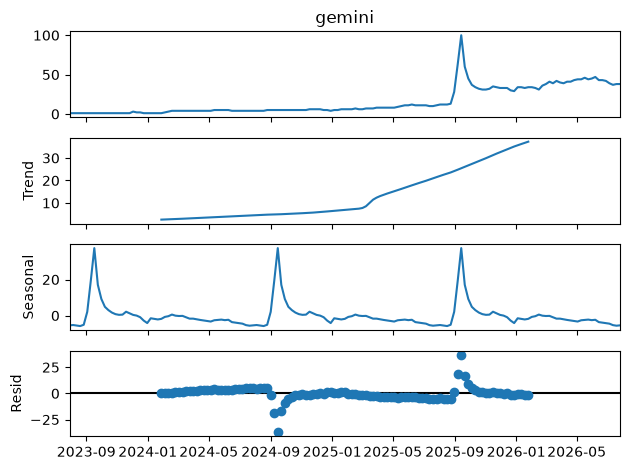

In [48]:
decompositions["gemini"].plot()
plt.show()

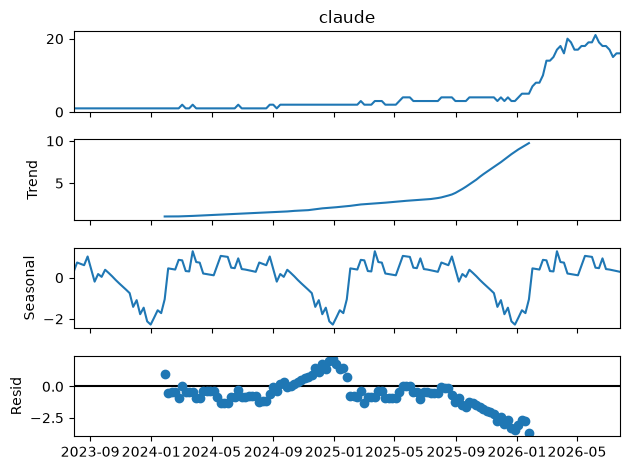

In [49]:
decompositions["claude"].plot()
plt.show()

## Şimdi 3'ünü aynanda karşılaştırma: 

In [56]:
# Üç ürünün trend başlangıç ve sonunu karşılaştırma

trend_summary= []

for i in decompositions.keys():
    trend= decompositions[i].trend.dropna()

    trend_summary.append({
        "ai": i,
        "first_trend": trend.iloc[0],
        "last_trend": trend.iloc[-1],
        "trend_change": trend.iloc[-1]-trend.iloc[0]
    })


In [57]:
# dataframe e dönüştürelim
import pandas as pd

trend_summary_df= pd.DataFrame(trend_summary)

trend_summary_df

,ai,first_trend,last_trend,trend_change
0,chatgpt,20.317308,73.730769,53.413462
1,gemini,2.586538,37.278846,34.692308
2,claude,1.057692,9.740385,8.682692


# Üç ürün arasında uzun vadeli ilgisi en fazla büyüyen hangisi?”

ChatGPT, incelediğimiz dönemin başında da açık ara en yüksek ilgiye sahipti ve uzun vadeli trendi yaklaşık 20’den 74’e çıktı. Yani hem başlangıçta güçlü hem de dönem sonunda hâlâ lider.

Gemini, çok düşük bir seviyeden başlamış ama yaklaşık 37’ye kadar yükselmiş. Dolayısıyla ChatGPT’nin seviyesine ulaşmamış olsa da çok güçlü bir büyüme göstermiş.

Claude da yükseliyor; yaklaşık 1’den 10’a çıkmış. Fakat Google arama ilgisi bakımından hâlâ diğer iki üründen oldukça düşük seviyede.

# Decomposition Kodunu `src` İçine Taşımak

Notebook keşif, deney ve yorumlama için kullanılır.

Tekrar kullanılabilir analiz işlemleri ise `src` içerisinde fonksiyon
haline getirilebilir.

Bu nedenle decomposition işlemi:

```text
src/time_series.py

dosyasına taşınmıştır.

decompose_series()
def decompose_series(
    series: pd.Series,
    period: int = 52,
    model: str = "additive",
) -> DecomposeResult:

fonksiyonu herhangi bir Pandas zaman serisine decomposition uygulamak için
kullanılabilir.

Bu sayede aynı kod ChatGPT, Gemini ve Claude için tekrar yazılmaz.

DecomposeResult

seasonal_decompose() normal bir sayı veya DataFrame yerine özel bir
decomposition sonucu döndürür.

Bu sonuç içerisinde:

observed
trend
seasonal
resid

bileşenleri bulunur.

DecomposeResult, bu dönüş değerinin tipini ifade eder.

Fonksiyonun:

-> DecomposeResult

şeklinde tanımlanması hem kodun ne döndürdüğünü açıklar hem de
Pylance'ın sonuç nesnesi üzerindeki özellikleri daha iyi tanımasına
yardımcı olur.

In [62]:
import os

os.getcwd()

'/Users/nihalapple/Desktop/trend-forecast-project/notebooks'

In [63]:
import sys

sys.path.append("..")

In [64]:
from src.time_series import decompose_series

In [77]:
chatgpt_from_src = decompose_series( # src kodumuz sayesinde uzun uzun yazmıyoz
    clean_data["chatgpt"]
)
"""clean_data["chatgpt"]
        ↓
decompose_series()
        ↓
src/time_series.py
        ↓
seasonal_decompose()
        ↓
DecomposeResult
        ↓
chatgpt_from_src"""

'clean_data["chatgpt"]\n        ↓\ndecompose_series()\n        ↓\nsrc/time_series.py\n        ↓\nseasonal_decompose()\n        ↓\nDecomposeResult\n        ↓\nchatgpt_from_src'

In [66]:
chatgpt_from_src.trend.dropna().head()

date
2024-01-28    20.317308
2024-02-04    20.461538
2024-02-11    20.634615
2024-02-18    20.836538
2024-02-25    21.067308
Name: trend, dtype: float64

In [67]:
chatgpt_decomposition.trend.dropna().head()

date
2024-01-28    20.317308
2024-02-04    20.461538
2024-02-11    20.634615
2024-02-18    20.836538
2024-02-25    21.067308
Name: trend, dtype: float64

In [69]:
is_same = chatgpt_from_src.trend.equals(
    chatgpt_decomposition.trend
)

is_same

True

* Notebook’ta elle yaptığımız decomposition ile src içindeki tekrar kullanılabilir fonksiyon aynı sonucu üretiyor.

In [72]:
import sys

sys.path.append("..")


In [74]:
import importlib
import src.time_series

importlib.reload(src.time_series)

<module 'src.time_series' from '/Users/nihalapple/Desktop/trend-forecast-project/notebooks/../src/time_series.py'>

In [75]:
from src.time_series import decomposition_to_dataframe

In [78]:
chatgpt_df = decomposition_to_dataframe(
    chatgpt_from_src
)

chatgpt_df.head()

,observed,trend,seasonal,residual,expected
date,,,,,
2023-07-30,13.0,NaN,-4.174464,NaN,NaN
2023-08-06,14.0,NaN,-1.193695,NaN,NaN
2023-08-13,14.0,NaN,-3.203310,NaN,NaN
2023-08-20,15.0,NaN,-1.150425,NaN,NaN
2023-08-27,16.0,NaN,1.931305,NaN,NaN


In [79]:
chatgpt_df.dropna().head()

,observed,trend,seasonal,residual,expected
date,,,,,
2024-01-28,20.0,20.317308,-2.400425,2.083118,17.916882
2024-02-04,20.0,20.461538,-1.597541,1.136002,18.863998
2024-02-11,21.0,20.634615,-2.179271,2.544656,18.455344
2024-02-18,21.0,20.836538,-1.746579,1.910041,19.089959
2024-02-25,22.0,21.067308,-2.337925,3.270618,18.729382


In [80]:
decomposition_df.dropna().head() # bu notebookda yaptığımız, aynı mı bakçaz

,observed,trend,seasonal,residual,yaklaşık beklenen,gözlemlenen
date,,,,,,
2024-01-28,20.0,20.317308,-2.400425,2.083118,17.9,20.0
2024-02-04,20.0,20.461538,-1.597541,1.136002,18.9,20.0
2024-02-11,21.0,20.634615,-2.179271,2.544656,18.5,21.0
2024-02-18,21.0,20.836538,-1.746579,1.910041,19.1,21.0
2024-02-25,22.0,21.067308,-2.337925,3.270618,18.7,22.0
